# **HANDS - ON: EXPLORACIÓN DE DATOS**



Una vez visto la presentación ***Exploración de datos***, se proporciona el siguiente ***colab*** para que **el alumnado pueda practicar** haciendo uso del lenguaje de programación ***python***.

Para este notebook, se hará uso del siguiente dataset: [enlace](https://drive.google.com/file/d/1hX8uxJp5h03eYrgAnyznp8yeeG2syiD_/view?usp=drive_link)

## **ANÁLISIS EXPLORATPRIO**

El **Análisis Exploratorio de Datos (EDA)** es la etapa donde **se descubren patrones, se detectan anomalías y se comprueban hipótesis mediante estadísticas y visualizaciones**. Es el proceso fundamental para entender la salud de la información antes de cualquier toma de decisiones.

A través de herramientas descriptivas y gráficos de dispersión, esta fase permite limpiar inconsistencias y validar la calidad de la muestra. Su ejecución garantiza que las conclusiones posteriores se apoyen en evidencia real, minimizando sesgos y optimizando la precisión de los modelos predictivos.

In [ ]:
# Importar librerías

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Importar datos

ruta_colab = '/content/youtube_clean.csv'
df_yt = pd.read_csv(ruta_colab)

df_yt

,video_id,título,categoría,views,likes,dislikes,comentarios,duración_min,fecha_publicación
0,1,título,música,129257,11299,21,8790,127,2024-07-02
1,2,título,películas,247904,15579,211,4775,63,2022-02-13
2,3,sin título,comedia,3073,14780,1095,9847,55,2016-07-06
3,4,título,gaming,268858,2691,4420,7614,78,2017-12-03
4,5,título,gaming,162893,16521,2294,6508,143,2023-11-24
...,...,...,...,...,...,...,...,...,...
303,106,título,películas,150272,11299,4605,6716,213,2021-09-04
304,131,título,tecnología,25407,9999999,2437,4498,137,2025-07-18
305,6,título,películas,42160,10721,3547,9033,58,2025-08-27
306,97,título,deportes,13530,14437,2631,2629,158,2018-03-12


In [ ]:
# Ver resumen estadístico de las columnas numéricas

columnas_numericas = ['views', 'likes', 'dislikes', 'comentarios', 'duración_min']
df_yt[columnas_numericas].describe()

,views,likes,dislikes,comentarios,duración_min
count,308.000000,3.080000e+02,308.000000,308.000000,308.000000
mean,144805.269481,6.265995e+05,12193.288961,5058.188312,139.853896
std,86246.543475,2.407311e+06,52900.153300,2940.396104,139.066834
min,1691.000000,9.700000e+01,21.000000,12.000000,1.000000
25%,74129.500000,5.774250e+03,1523.750000,2667.500000,58.000000
50%,129257.000000,1.129900e+04,2590.000000,4931.500000,123.500000
75%,224050.750000,1.575300e+04,3777.500000,7740.750000,181.500000
max,299408.000000,9.999999e+06,300408.000000,9987.000000,800.000000


### **VALORES ATÍPICOS Y TRATAMIENTO**

**Los valores atípicos son observaciones que se alejan significativamente del resto de los datos**. Pueden ser causados por errores en la entrada de datos o por fenómenos naturales del dataset.

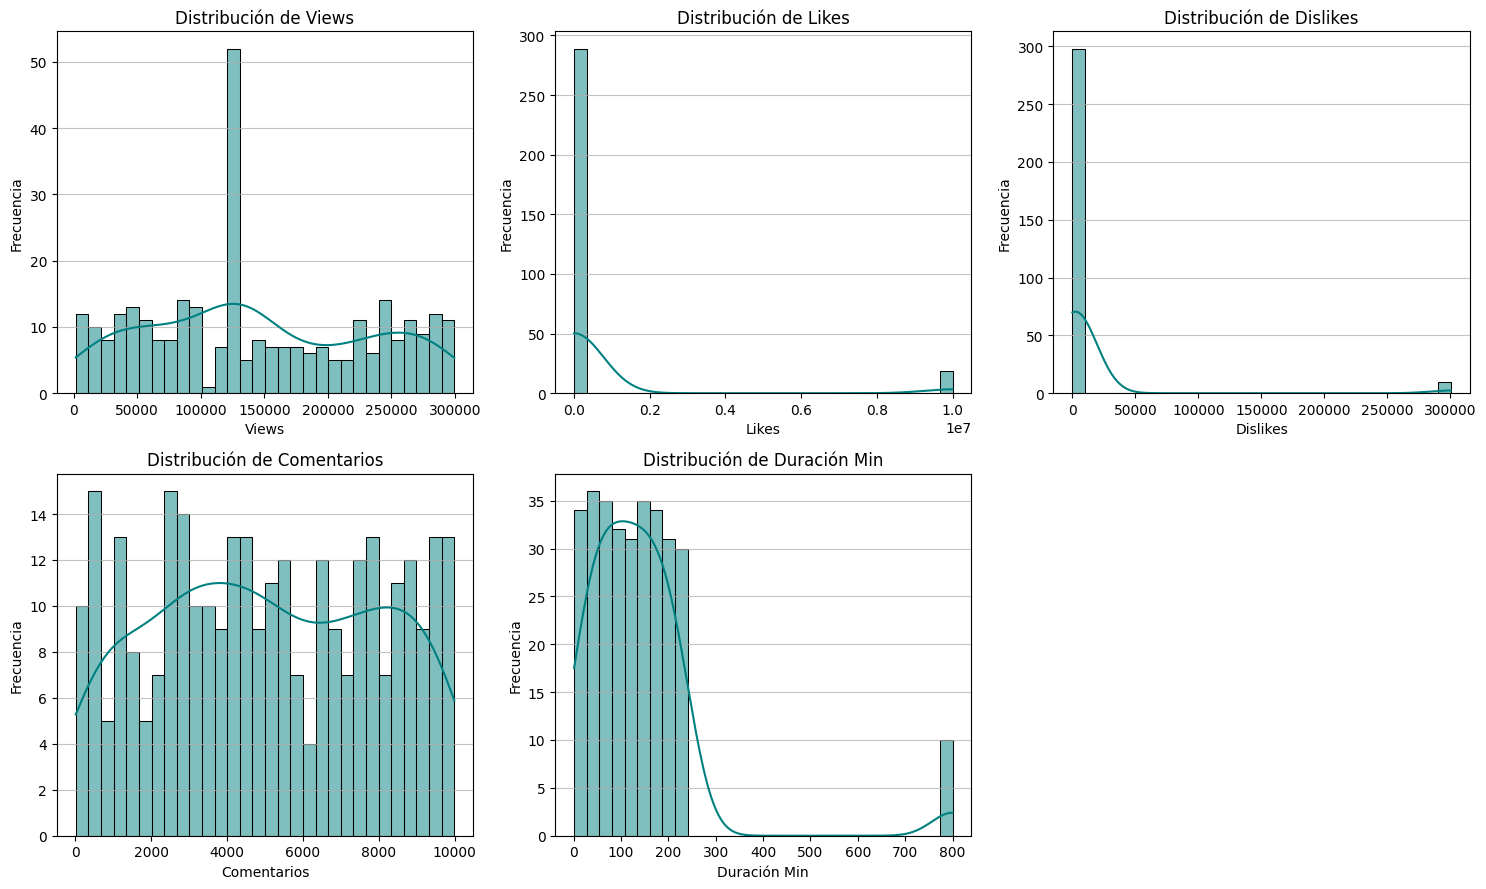

In [ ]:
# Observar distribución de los datos

plt.figure(figsize=(15, 9))

for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df_yt[col], bins=30, kde=True, color='teal')
    plt.title(f'Distribución de {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Frecuencia')
    plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

# Todas las distribuciones no son normales y casi todos tienen valores extremos

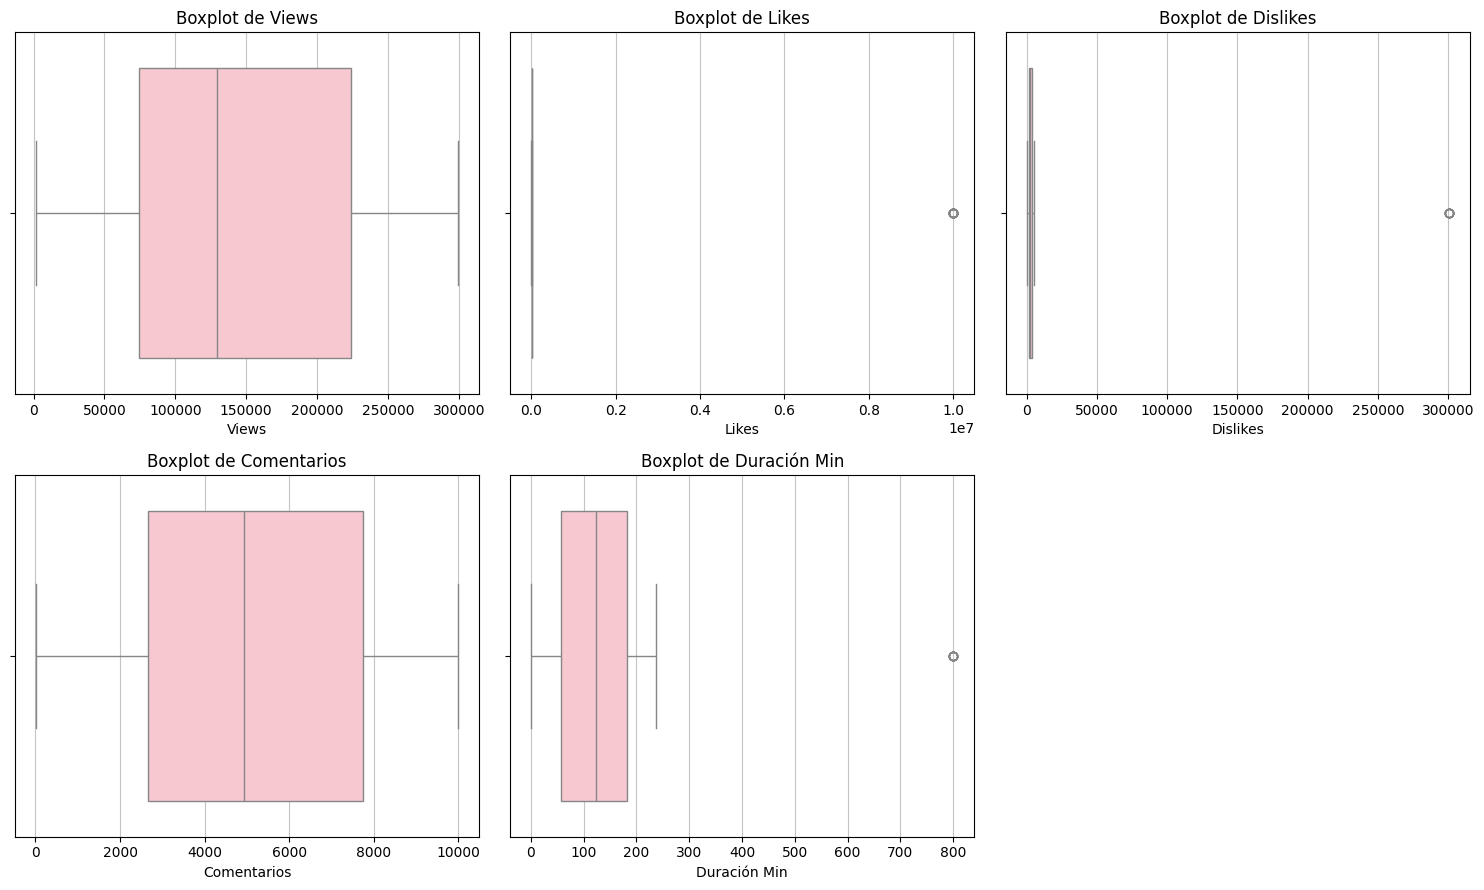

In [ ]:
# Observar comportamiento cuartil de los datos

plt.figure(figsize=(15, 9))

for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df_yt[col], color='pink')
    plt.title(f'Boxplot de {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.grid(axis='x', alpha=0.75)

plt.tight_layout()
plt.show()

# Tres gráficos de caja presentan valores extremos

#### **RANGO INTERCUARTILICO**

El **Rango Intercuartílico (IQR)** es una medida fundamental de dispersión estadística, utilizada principalmente para detectar y manejar **valores atípicos (outliers)** en un conjunto de datos. Se calcula como la diferencia entre el tercer cuartil (Q3) y el primer cuartil (Q1):

$$IQR = Q3 - Q1$$

Para identificar outliers, se definen límites:

*   **Límite Inferior (LI):** $LI = Q1 - 1.5 \times IQR$

*   **Límite Superior (LS):** $LS = Q3 + 1.5 \times IQR$


In [ ]:
# Ver cantidad de registros iniciales

print(f"Cantidad de datos iniciales: {len(df_yt)}")

Cantidad de datos iniciales: 308


In [ ]:
# Calculo del IQR

df_copy = df_yt.copy() # preservar el dataset haciendo una copia

for col in columnas_numericas:

    Q1 = df_copy[col].quantile(0.25) # Primer cuartil
    Q3 = df_copy[col].quantile(0.75) # Tercer cuartil
    IQR = Q3 - Q1 # Rango Intercuartilico

    lim_inf_iqr = Q1 - 1.5 * IQR # Límite inferior
    lim_sup_iqr = Q3 + 1.5 * IQR # Límite superior

    cant_inicial = len(df_copy)
    # Filtro de los datos dentro de los límites
    df_copy = df_copy[(df_copy[col] >= lim_inf_iqr) & (df_copy[col] <= lim_sup_iqr)]
    cant_final = len(df_copy)

    print(f"Columna '{col}': Se eliminaron {cant_inicial - cant_final} registros.")

Columna 'views': Se eliminaron 0 registros.
Columna 'likes': Se eliminaron 19 registros.
Columna 'dislikes': Se eliminaron 10 registros.
Columna 'comentarios': Se eliminaron 0 registros.
Columna 'duración_min': Se eliminaron 10 registros.


In [ ]:
# Ver cantidad de registros finales y proporción con la cantidad inicial

prop_cant_datos = round((len(df_copy) / len(df_yt)) * 100, 2)

print(f"Cantidad de datos finales: {len(df_copy)}")
print(f"Los datos finales representan el {prop_cant_datos}% de los datos iniciales")

Cantidad de datos finales: 269
Los datos finales representan el 87.34% de los datos iniciales


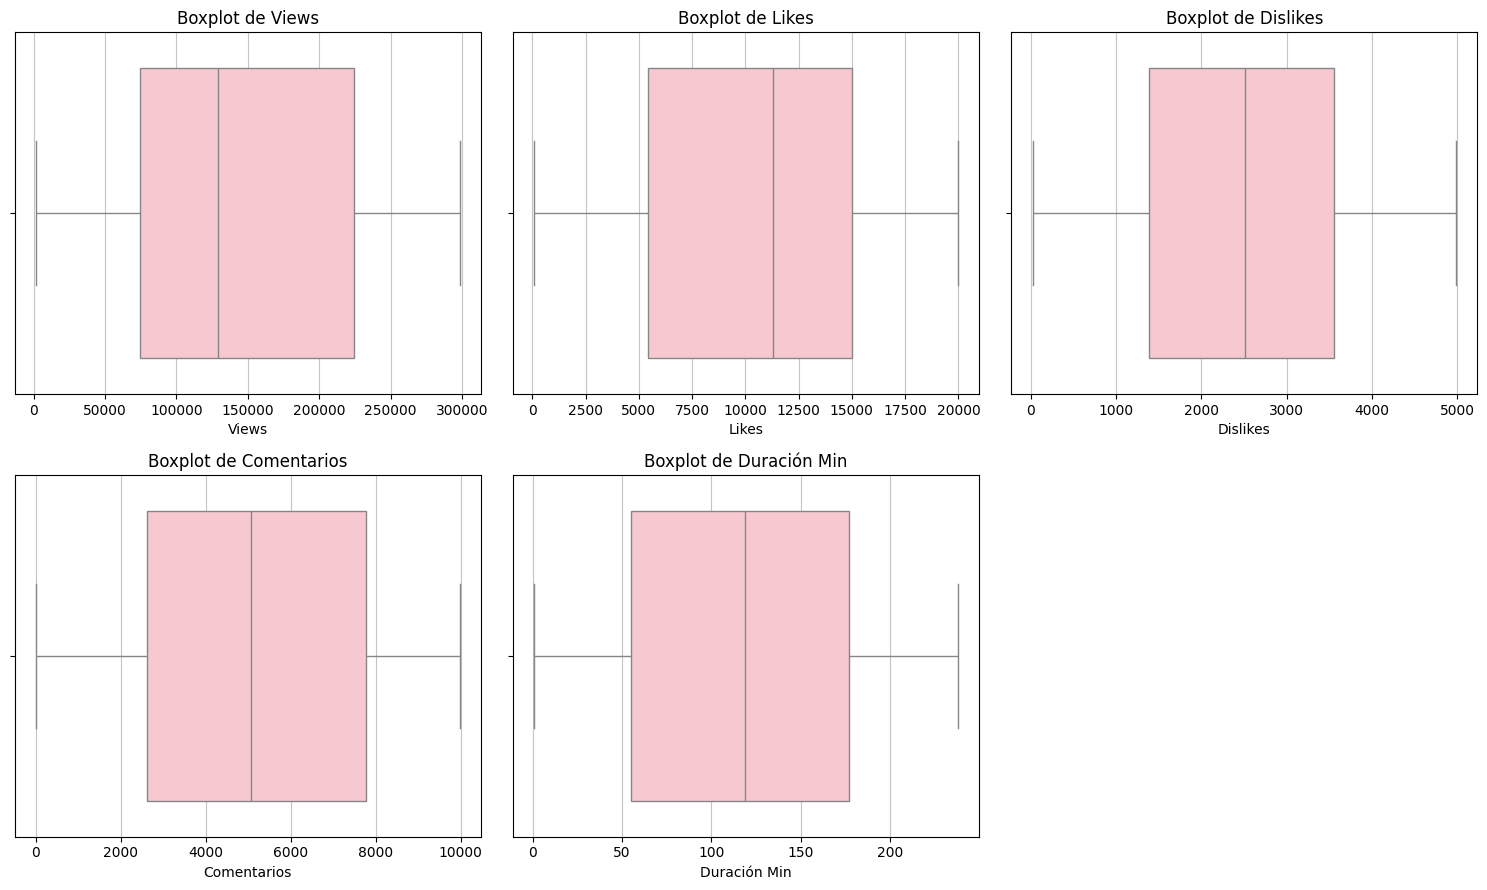

In [ ]:
# Observar comportamiento cuartil final de los datos

plt.figure(figsize=(15, 9))

for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df_copy[col], color='pink')
    plt.title(f'Boxplot de {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.grid(axis='x', alpha=0.75)

plt.tight_layout()
plt.show()

### **CORRELACIÓN NUMÉRICA**

La **correlación numérica** es una medida estadística que **indica la fuerza y dirección de la relación lineal entre dos o más variables numéricas**. Puede utilizar el coeficiente de correlación de Pearson (el más común) para determinar la dirección (positiva, negativa, nula).

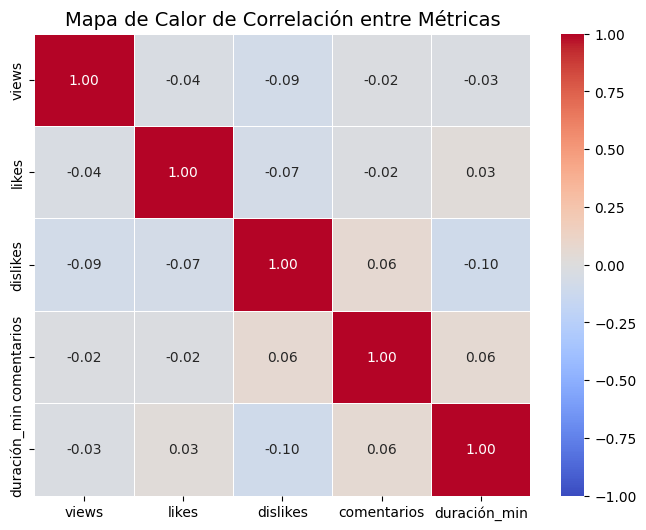

In [ ]:
# Realizar matriz de correlación

corr_matrix = df_copy[['views', 'likes', 'dislikes', 'comentarios', 'duración_min']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

plt.title('Mapa de Calor de Correlación entre Métricas', fontsize=14)
plt.show()

# Los coeficientes de las intersecciones convergen en 0, no hay correlación

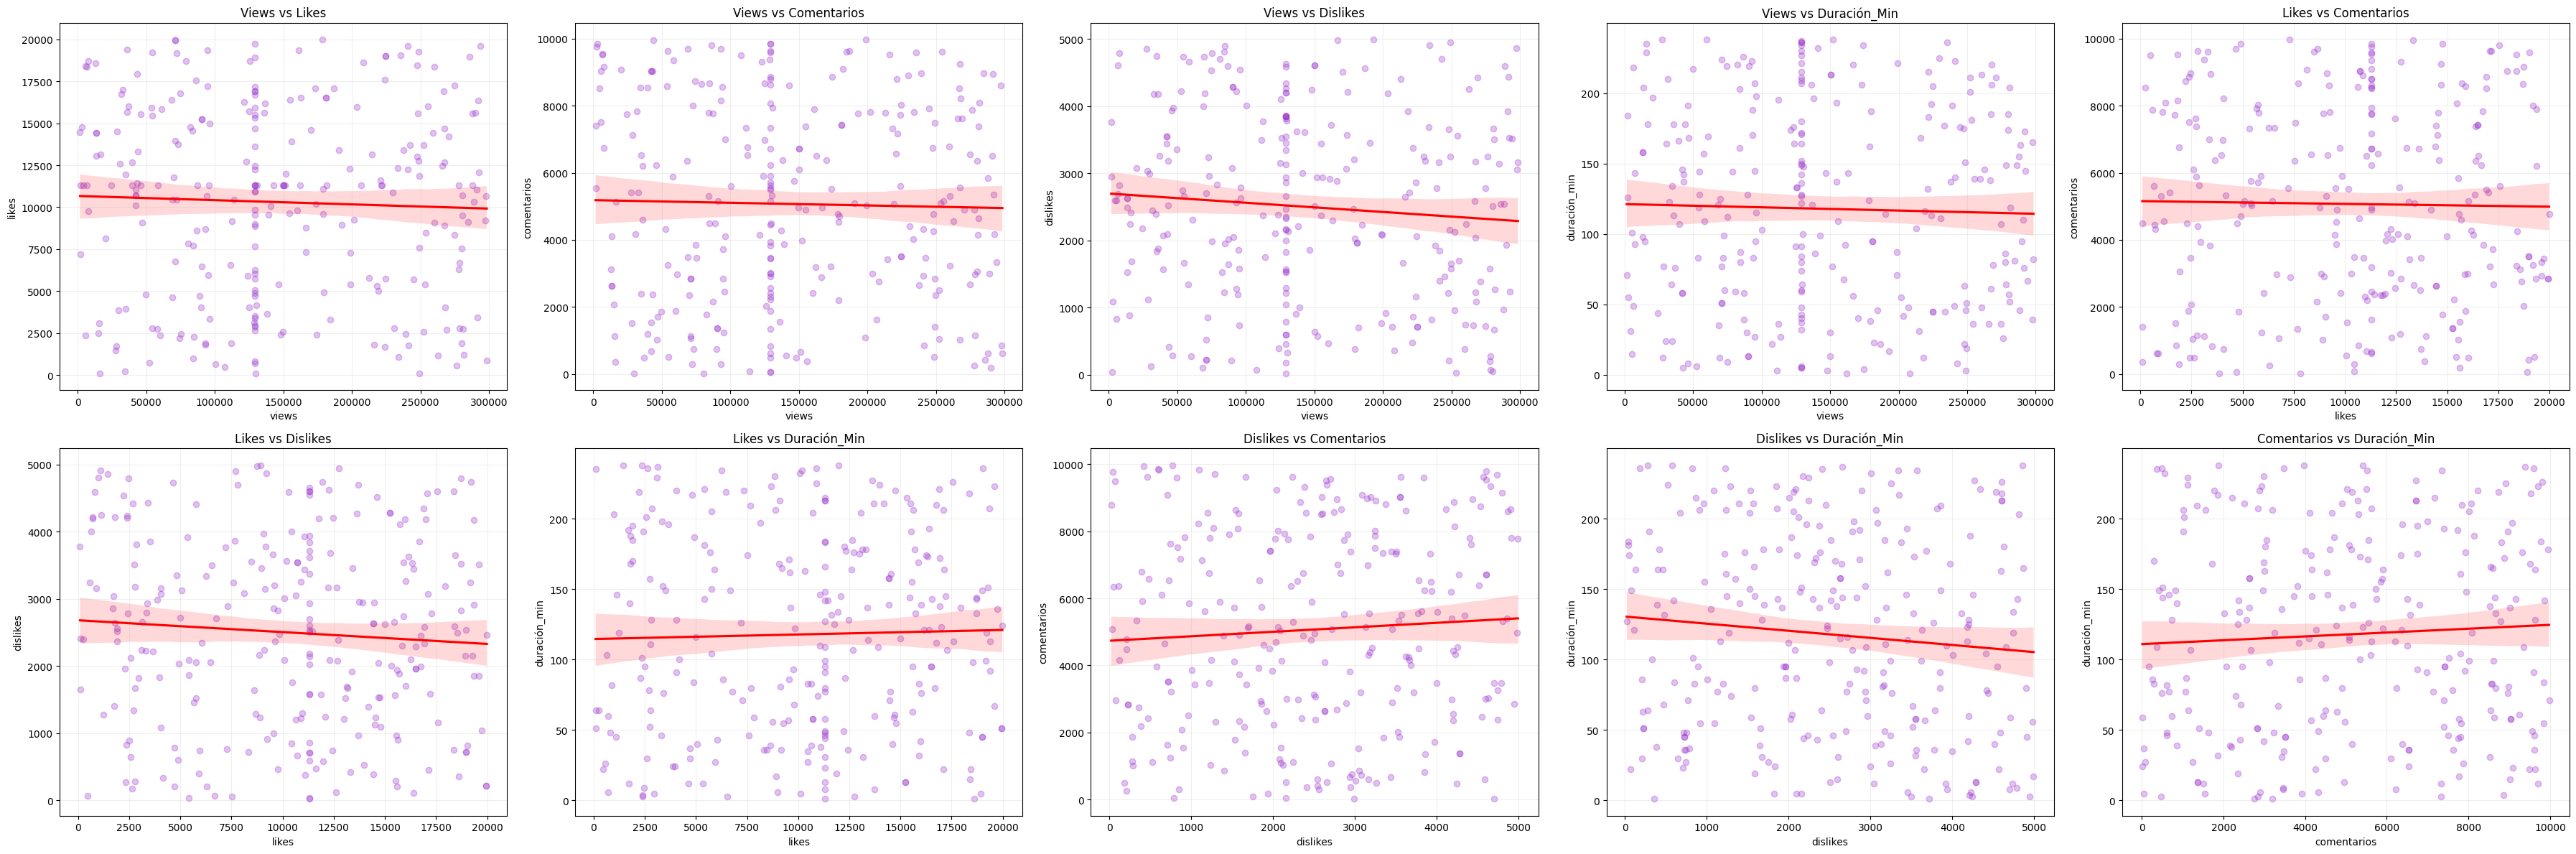

In [ ]:
# Realizar correlaciones divididas

metricas = ['views', 'likes', 'dislikes', 'comentarios', 'duración_min']

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(36, 12))
axes = axes.flatten() # Aplanamos para iterar fácilmente

# Pares de comparación por
comparaciones = [
    ('views', 'likes'), ('views', 'comentarios'), ('views', 'dislikes'),
    ('views', 'duración_min'), ('likes', 'comentarios'), ('likes', 'dislikes'),
    ('likes', 'duración_min'), ('dislikes', 'comentarios'),
    ('dislikes', 'duración_min'), ('comentarios', 'duración_min')
]

for i, (col_x, col_y) in enumerate(comparaciones):
    sns.regplot(ax=axes[i], data=df_copy, x=col_x, y=col_y,
                scatter_kws={'alpha':0.3, 'color':'darkorchid'},
                line_kws={'color':'red'})
    axes[i].set_title(f'{col_x.title()} vs {col_y.title()}')
    axes[i].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# Al no haber correlaciones, los datos se muestran dispersos

#### **COMPARACIÓN POR CATEGÓRICA**

La **comparación por categórica** implica analizar cómo las variables numéricas se comportan o distribuyen a través de diferentes grupos o categorías. Este tipo de análisis es fundamental para entender: **distribuciones, tendencias y relaciones**

Para visualizar estas comparaciones, son muy útiles los **gráficos de barras**, donde se pueden mostrar las cantidades o promedios de una variable numérica para cada categoría, o los **diagramas de caja (boxplots)**, que revelan la distribución completa de los datos dentro de cada grupo, incluyendo la mediana, cuartiles y posibles valores atípicos.

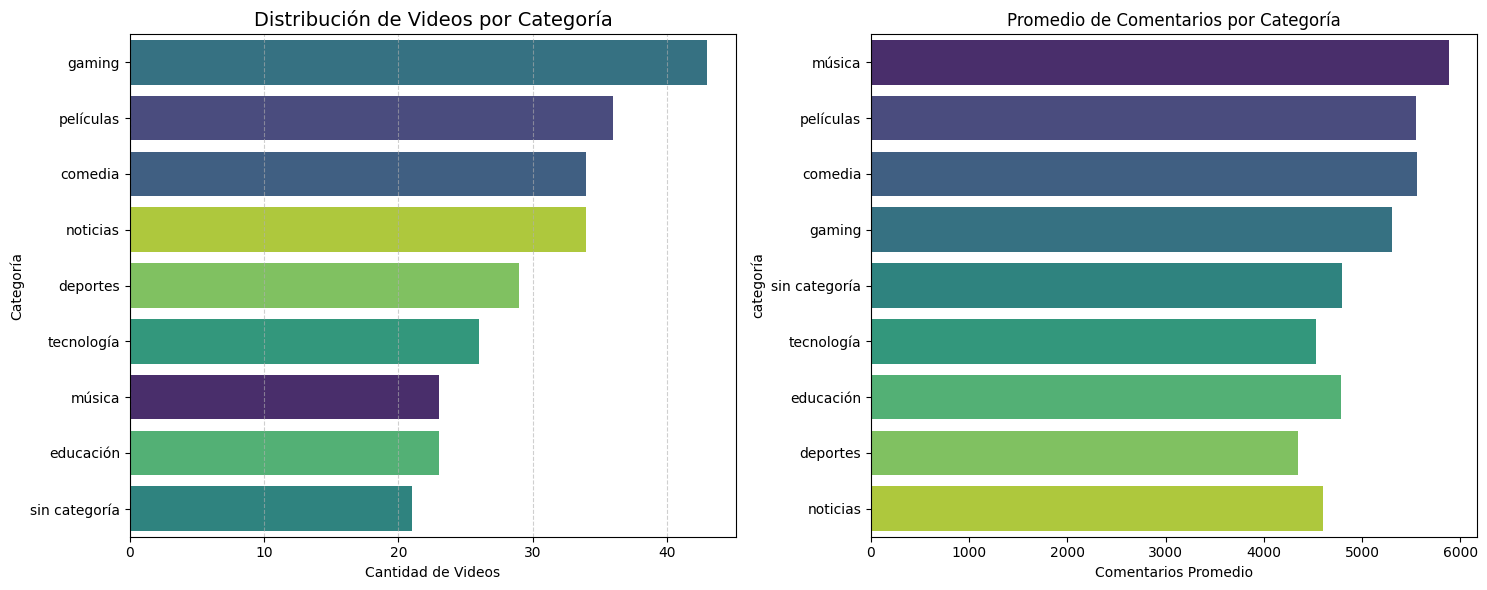

In [ ]:
# Realizar gráficos de barras divididas

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
orden = df_copy['categoría'].value_counts().index # Ordenar de mayor a menor
sns.countplot(data=df_copy, y='categoría', order=orden, palette='viridis', hue='categoría', legend=False)
plt.title('Distribución de Videos por Categoría', fontsize=14)
plt.xlabel('Cantidad de Videos')
plt.ylabel('Categoría')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
sns.barplot(data=df_copy, x='comentarios', y='categoría',
            estimator='mean', palette='viridis', errorbar=None, hue='categoría', legend=False)
plt.title('Promedio de Comentarios por Categoría')
plt.xlabel('Comentarios Promedio')

plt.tight_layout()
plt.show()

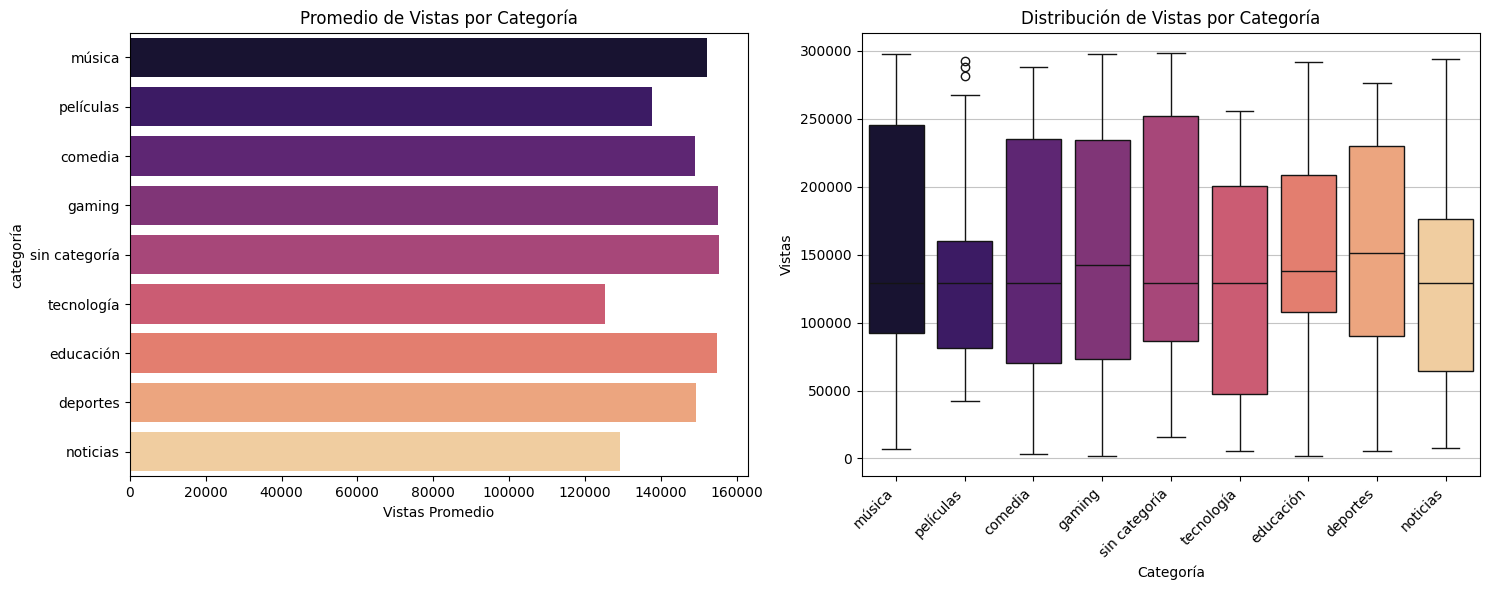

In [ ]:
# Realizar gráfico de barras y caja divididos

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.barplot(data=df_copy, x='views', y='categoría',
            estimator='mean', palette='magma', errorbar=None, hue='categoría', legend=False)
plt.title('Promedio de Vistas por Categoría')
plt.xlabel('Vistas Promedio')

plt.subplot(1, 2, 2)
sns.boxplot(data=df_copy, x='categoría', y='views', palette='magma', hue='categoría', legend=False)
plt.title('Distribución de Vistas por Categoría')
plt.xlabel('Categoría')
plt.ylabel('Vistas')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

## **NARRATIVA VISUAL**

La **visualización narrativa** es la fusión estratégica entre la **claridad de los gráficos** y el **impacto del storytelling para comunicar mensajes** memorables. No se limita a exponer cifras, sino que construye un relato donde los datos actúan como evidencia para guiar a la audiencia hacia una conclusión clara.

Al conectar puntos de datos con una estructura narrativa, se logra captar la atención emocional y lógica del espectador. Esta técnica transforma estadísticas frías en una historia coherente, facilitando la comprensión de tendencias complejas y asegurando que los hallazgos clave impulsen una toma de decisiones informada.

### **PROPORCIÓN DE DATOS A MOSTRAR**

In [ ]:
# Definir variables para la agrupación

categoria = lambda x: 'Sin Categoría' if x == 'sin categoría' else 'Con Categoría'
df_yt['agrupacion_cat'] = df_yt['categoría'].apply(categoria)
pie_data = df_yt['agrupacion_cat'].value_counts()

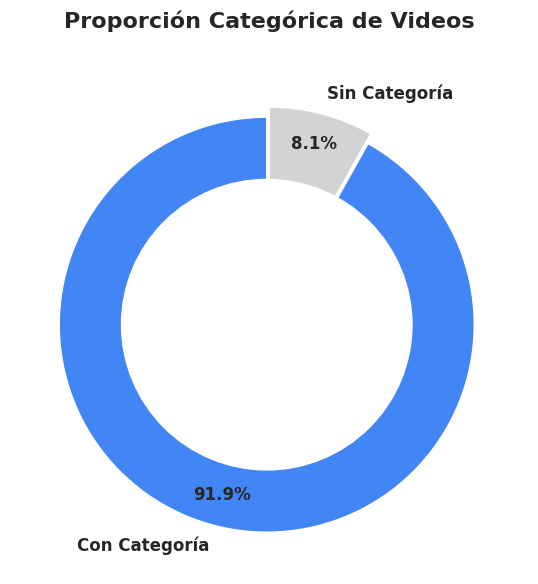

In [ ]:
# Realizar gráfico de dona

colors_pie = ['#4285F4', '#D3D3D3'] # Azul = "Con Categoría", Gris = "Sin Categoría"
explode_val = 0.05 # Valor de separación

# Gráfico de pastel

plt.figure(figsize=(6, 6))
wedges, texts, autotexts = plt.pie(pie_data,
                                   labels=pie_data.index,
                                   autopct='%1.1f%%',
                                   startangle=90,
                                   colors=colors_pie,
                                   textprops={'fontsize': 12, 'fontweight': 'bold'},
                                   pctdistance=0.85, # Mueve el porcentaje hacia afuera
                                   explode=(explode_val, 0)) # Resalta ligeramente la porción principal

# Círculo blanco central (estilo moderno)

theta1, theta2 = wedges[0].theta1, wedges[0].theta2
center_angle = np.deg2rad((theta1 + theta2) / 2) # Obtención el ángulo medio

cx = explode_val * np.cos(center_angle) # Se Calcula nueva posición con trigonometría
cy = explode_val * np.sin(center_angle)

centre_circle = plt.Circle((cx, cy), 0.70, fc='white') # Se dibuja el circulo
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Proporción Categórica de Videos', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### **DISTRIBUCIÓN DE VÍDEOS POR CATEGORÍA**

In [ ]:
# Definir variables

df_filtrado = df_yt[df_yt['categoría'] != 'sin categoría']
counts = df_filtrado['categoría'].value_counts()
order = counts.index
values = counts.values

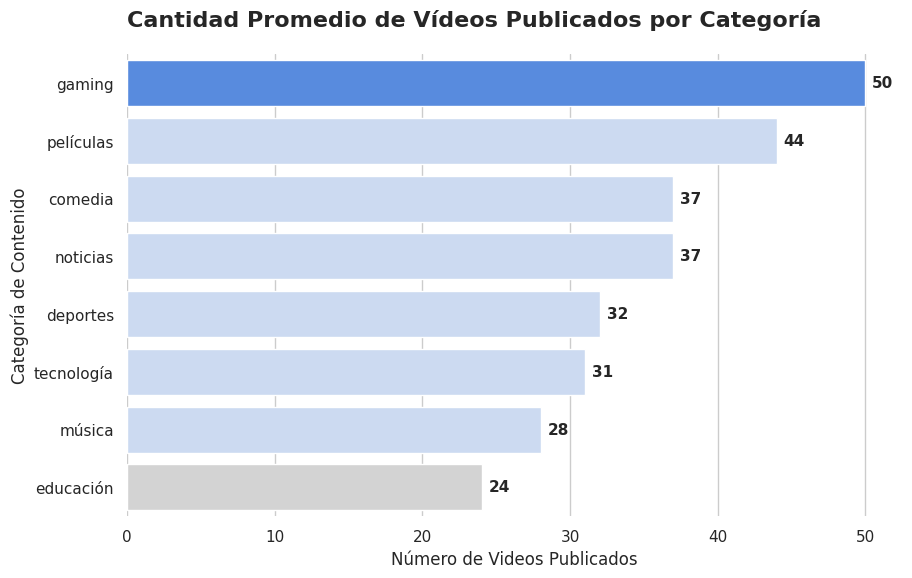

In [ ]:
# Realizar gráfico de barras

colors = ['#4285F4' if v == values.max() else '#D3D3D3' if v == values.min() else '#C6D9F7' for v in values]

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(x=values, y=order, palette=colors, hue=order, legend=False)

for p in ax.patches: # Etiquetas de datos
    ax.annotate(f'{int(p.get_width())}',
                (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=11, fontweight='bold', xytext=(5, 0), textcoords='offset points')

plt.title('Cantidad Promedio de Vídeos Publicados por Categoría', loc='left', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Número de Videos Publicados')
plt.ylabel('Categoría de Contenido')
sns.despine(left=True, bottom=True)
plt.show()

### **PROMEDIO DE VISTAS POR CATEGORÍA**

In [ ]:
# Definir variables

vistas_mean = df_yt.groupby('categoría')['views'].mean().sort_values(ascending=False)
colors_vistas = ['#4285F4' if v == vistas_mean.max() else '#D3D3D3' if v == vistas_mean.min() else '#C6D9F7' for v in vistas_mean]

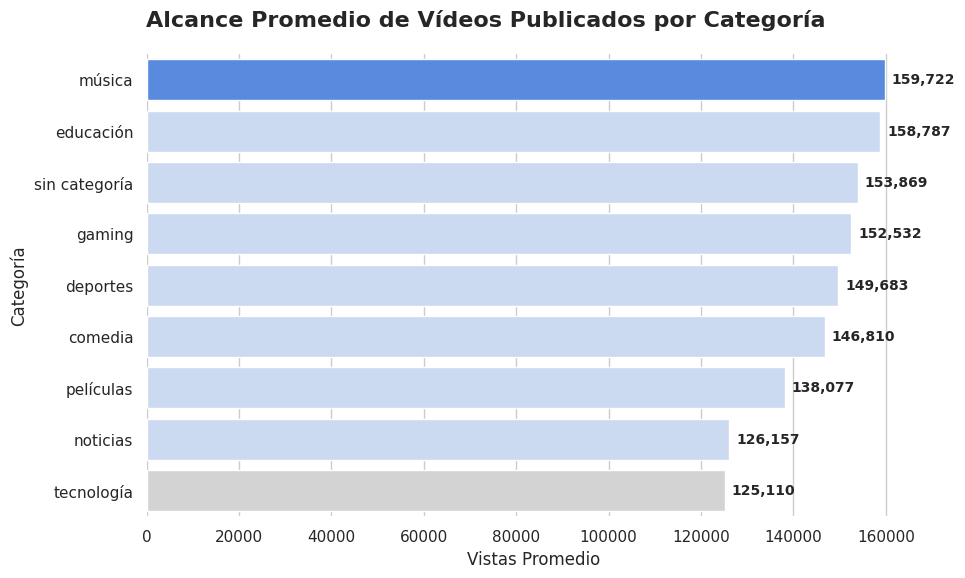

In [ ]:
# Realizar gráfico de barras

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax1 = sns.barplot(x=vistas_mean.values, y=vistas_mean.index, palette=colors_vistas, hue=vistas_mean.index, legend=False)

for p in ax1.patches: # Etiquetas y estética
    ax1.annotate(f'{int(p.get_width()):,}', (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=10, fontweight='bold', xytext=(5, 0), textcoords='offset points')

plt.title('Alcance Promedio de Vídeos Publicados por Categoría', loc='left', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Vistas Promedio')
plt.ylabel('Categoría')
sns.despine(left=True, bottom=True)
plt.show()

### **PROMEDIO DE COMENTARIOS POR CATEGORÍA**

In [ ]:
# Definir variables

coments_mean = df_yt.groupby('categoría')['comentarios'].mean().sort_values(ascending=False)
colors_coments = ['#4285F4' if v == coments_mean.max() else '#D3D3D3' if v == coments_mean.min() else '#C6D9F7' for v in coments_mean]

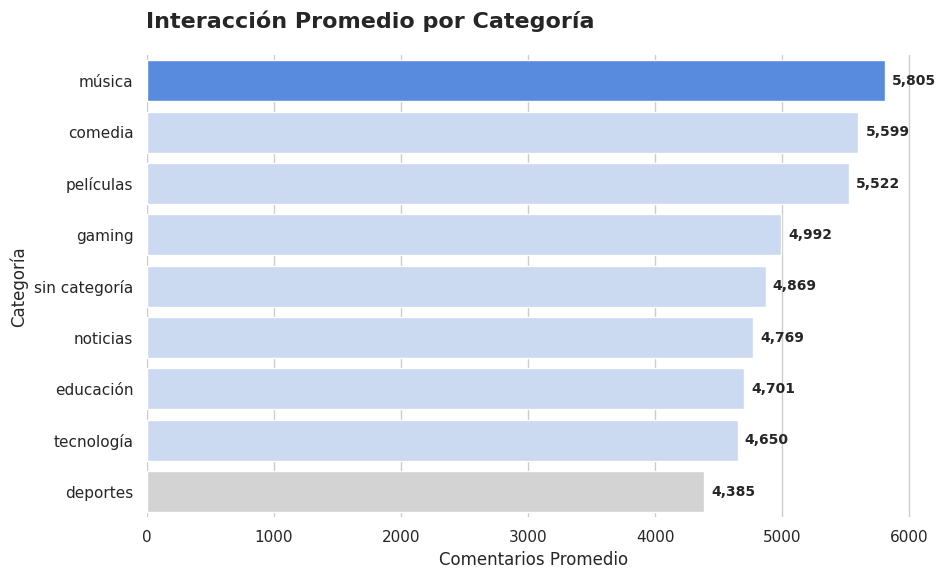

In [ ]:
# Realizar gráfico de barras

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax2 = sns.barplot(x=coments_mean.values, y=coments_mean.index, palette=colors_coments, hue=coments_mean.index, legend=False)

for p in ax2.patches: # Etiquetas y estética
    ax2.annotate(f'{int(p.get_width()):,}', (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=10, fontweight='bold', xytext=(5, 0), textcoords='offset points')

plt.title('Interacción Promedio por Categoría', loc='left', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Comentarios Promedio')
plt.ylabel('Categoría')
sns.despine(left=True, bottom=True)
plt.show()